In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# --- CONFIG ---
VOL_SIZE = 32
N_SAMPLES = 10000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def generate_distance_data(n_samples, swapped=False):
    X = torch.zeros((n_samples, 1, VOL_SIZE, VOL_SIZE, VOL_SIZE))
    Y = torch.randint(0, 2, (n_samples,)).float()
    
    for i in range(n_samples):
        label = Y[i]
        # Class 0: Close (4), Class 1: Far (12)
        dist = 4 if label == 0 else 12
        
        if not swapped:
            # TRAIN: Class 0 @ Left, Class 1 @ Right
            start_x = np.random.randint(2, 6) if label == 0 else np.random.randint(14, 18)
        else:
            # TEST: Class 0 @ Right, Class 1 @ Left
            start_x = np.random.randint(14, 18) if label == 0 else np.random.randint(2, 6)
            
        y, z = np.random.randint(10, 20, size=2)
        # Dots are slightly larger (3x3x3) to be more visible in frequency domain
        X[i, 0, start_x:start_x+3, y:y+3, z:z+3] = 1.0
        X[i, 0, start_x+dist:start_x+dist+3, y:y+3, z:z+3] = 1.0
        
    return X, Y

# --- MODELS ---

class SpectralViT(nn.Module):
    def __init__(self, total_bins=32768, n_samples=2048, n_tokens=32, embed_dim=64):
        super(SpectralViT, self).__init__()
        # FIX: We sample 2048 indices across the WHOLE spectrum, not just the first 2048
        # This ensures we see the "fringes" created by the distance between dots
        indices = torch.linspace(0, total_bins - 1, n_samples).long()
        self.register_buffer('indices', indices)
        
        self.feat_per_token = n_samples // n_tokens
        self.n_tokens = n_tokens
        self.proj = nn.Linear(self.feat_per_token, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, dim_feedforward=128)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.mlp_head = nn.Linear(embed_dim, 1)

    def forward(self, x):
        b = x.shape[0]
        # x is FFT Magnitude. Flatten and sample across the spectrum
        x = x.view(b, -1)[:, self.indices]
        x = x.view(b, self.n_tokens, self.feat_per_token)
        x = self.proj(x).transpose(0, 1) 
        x = self.transformer(x)
        return self.mlp_head(x.mean(dim=0)).squeeze(-1)

class SpatialViT(nn.Module):
    def __init__(self, vol_size=32, patch_size=8, embed_dim=64):
        super(SpatialViT, self).__init__()
        self.n_patches = (vol_size // patch_size) ** 3
        self.proj = nn.Linear(patch_size ** 3, embed_dim)
        # Position is the "cheat" for the training set
        self.pos_embed = nn.Parameter(torch.randn(self.n_patches, 1, embed_dim) * 2.0) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, dim_feedforward=128)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.mlp_head = nn.Linear(embed_dim, 1)

    def forward(self, x):
        b, p = x.shape[0], 8
        x = x.unfold(2, p, p).unfold(3, p, p).unfold(4, p, p).contiguous().view(b, self.n_patches, -1)
        x = self.proj(x).transpose(0, 1) + self.pos_embed
        x = self.transformer(x)
        return self.mlp_head(x.mean(dim=0)).squeeze(-1)

# --- EXECUTION ---

print("Generating Distance Data (Swapped Positions)...")
X_train, Y_train = generate_distance_data(1000, swapped=False)
X_test, Y_test = generate_distance_data(200, swapped=True)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=32)

m_spec, m_spat = SpectralViT().to(DEVICE), SpatialViT().to(DEVICE)
opt_spec, opt_spat = optim.Adam(m_spec.parameters(), lr=1e-3), optim.Adam(m_spat.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

print(f"\n{'Epoch':<6} | {'Spec Test Acc':<15} | {'Spat Test Acc':<15}")
print("-" * 45)

for epoch in range(1, 101):
    m_spec.train(); m_spat.train()
    for b_vol, b_y in train_loader:
        b_vol, b_y = b_vol.to(DEVICE), b_y.to(DEVICE)
        b_fft = torch.abs(torch.fft.fftn(b_vol, dim=(-3, -2, -1)))
        
        opt_spec.zero_grad(); criterion(m_spec(b_fft), b_y).backward(); opt_spec.step()
        opt_spat.zero_grad(); criterion(m_spat(b_vol), b_y).backward(); opt_spat.step()

    m_spec.eval(); m_spat.eval(); acc_spec, acc_spat, total = 0, 0, 0
    with torch.no_grad():
        for b_vol, b_y in test_loader:
            b_vol, b_y = b_vol.to(DEVICE), b_y.to(DEVICE)
            b_fft = torch.abs(torch.fft.fftn(b_vol, dim=(-3, -2, -1)))
            acc_spec += ((torch.sigmoid(m_spec(b_fft)) > 0.5).float() == b_y).sum().item()
            acc_spat += ((torch.sigmoid(m_spat(b_vol)) > 0.5).float() == b_y).sum().item()
            total += b_y.size(0)
    print(f"{epoch:<6} | {acc_spec/total:<15.2%} | {acc_spat/total:<15.2%}")

Generating Distance Data (Swapped Positions)...

Epoch  | Spec Test Acc   | Spat Test Acc  
---------------------------------------------
1      | 53.00%          | 53.00%         
2      | 100.00%         | 53.00%         
3      | 100.00%         | 14.00%         
4      | 100.00%         | 12.50%         
5      | 100.00%         | 11.50%         
6      | 100.00%         | 10.50%         
7      | 100.00%         | 10.50%         
8      | 100.00%         | 10.50%         
9      | 100.00%         | 10.50%         
10     | 100.00%         | 10.50%         
11     | 100.00%         | 10.50%         
12     | 100.00%         | 10.50%         
13     | 100.00%         | 10.50%         
14     | 100.00%         | 10.50%         
15     | 100.00%         | 10.50%         
16     | 100.00%         | 10.50%         
17     | 100.00%         | 10.50%         
18     | 100.00%         | 10.50%         
19     | 100.00%         | 10.50%         
20     | 100.00%         | 11.00%         
21

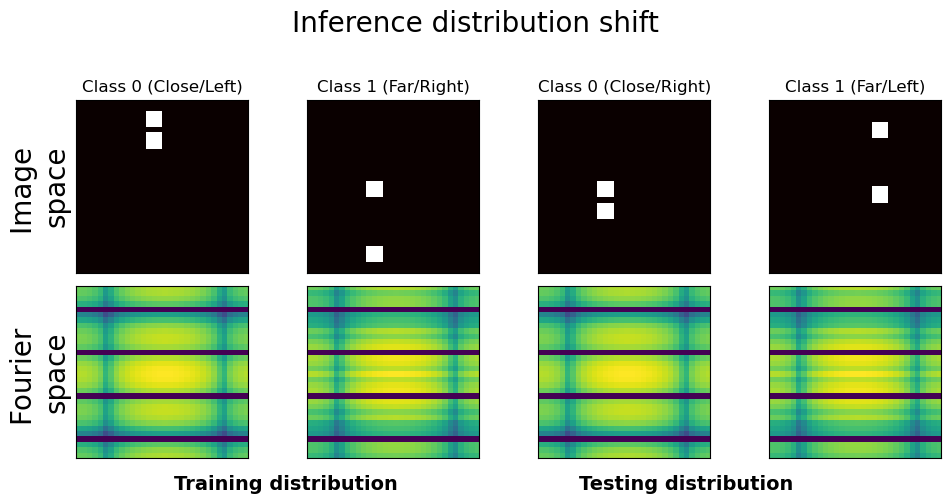

In [3]:
import matplotlib.pyplot as plt

def visualize_task_fixed():
    # Generate samples
    X_train, Y_train = generate_distance_data(10, swapped=False)
    X_test, Y_test = generate_distance_data(10, swapped=True)

    # Find one of each class from train and test
    idx_t0 = (Y_train == 0).nonzero()[0].item()
    idx_t1 = (Y_train == 1).nonzero()[0].item()
    idx_s0 = (Y_test == 0).nonzero()[0].item()
    idx_s1 = (Y_test == 1).nonzero()[0].item()

    samples = [X_train[idx_t0], X_train[idx_t1], X_test[idx_s0], X_test[idx_s1]]
    titles = ["Class 0 (Close/Left)", "Class 1 (Far/Right)", 
              "Class 0 (Close/Right)", "Class 1 (Far/Left)"]

    fig, axes = plt.subplots(2, 4, figsize=(10, 5), facecolor='white')
    
    for i, (vol, title) in enumerate(zip(samples, titles)):
        # 1. SPATIAL VIEW: Use Max Projection instead of a single slice
        # This ensures we see the dots regardless of where they are in 3D
        spatial_proj = torch.max(vol[0], dim=1)[0].numpy()
        
        axes[0, i].imshow(spatial_proj, cmap='hot', vmin=0, vmax=1)
        axes[0, i].set_title(f"{title}", fontsize=12)
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])

        # 2. FOURIER VIEW: 2D FFT of the projection
        f = torch.fft.fft2(torch.from_numpy(spatial_proj))
        f_shift = torch.fft.fftshift(torch.abs(f))
        # Use a small epsilon and log scale to see the fringes
        f_mag = torch.log(f_shift + 1e-3).numpy()
        
        axes[1, i].imshow(f_mag, cmap='viridis')
        #axes[1, i].set_title("Fourier tokenization", fontsize=20)
        axes[1, i].set_xticks([])
        axes[1, i].set_yticks([])

    plt.suptitle('Inference distribution shift',fontsize=20)
    axes[0,0].set_ylabel('Image \nspace',fontsize=20)
    axes[1,0].set_ylabel('Fourier \nspace',fontsize=20)
    
    # Add centered labels at the bottom for Train and Test groups
    fig.text(0.31, 0.02, 'Training distribution', ha='center', fontsize=14, fontweight='bold')
    fig.text(0.71, 0.02, 'Testing distribution', ha='center', fontsize=14, fontweight='bold')

    # Use rect to prevent tight_layout from overlapping the suptitle and bottom labels
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

visualize_task_fixed()